# Neighborhood analysis with just immune cells and based on comparisons of interest

Poportions will be calculated based on the subset of immune cells in each ROI.

In [138]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import time
import sys
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import seaborn as sns
import math
import os
import re

from scipy.spatial import cKDTree
from scipy.spatial import distance_matrix
from scipy.stats import ttest_ind
from itertools import combinations
import pandas as pd
import statsmodels.stats.multitest as smm

import matplotlib.cm as cm
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

I am working with these ROIs in here:

In [139]:
path = "/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/"

all_files = os.listdir(path)
pattern = re.compile(r'(.+)_sigma_binary_res')

# Extract matching sample names
sample_names = []
for file in all_files:
    match = pattern.match(file)
    if match:
        sample_names.append(match.group(1)) 

In [140]:
sample_names

['23257_A7_T3_tumor_bed',
 'S24-35674_A9_peritumoral_area',
 'BMS23-6679_C_tumor',
 'S23-38315_A3_tumor_inner',
 'BMS23-11362_C8_tumor_inner',
 'BMSS23-8749_28835_tumor',
 'S24-30054_A11_T3_entire_image',
 'S24-12214_C1_tumor',
 'BMS23-9784_A6_31737_tumor_bed',
 'S24-22889_A6_tumor_inner',
 'S24-22889_A6_peritumoral_area',
 'S23-47115_A6_tumor_bed',
 'S24-11672_G1_tumor',
 'S23-18584_A5_tumor_bed',
 'S24-35674_A9_tumor_inner',
 'S24-21915_A5_tumor_bed',
 'S23-21917_A6_tumor_bed',
 'BMS23-7393_C_tumor',
 'BMS24-11260_D_tumor',
 'S23-38315_A3_peritumoral_area',
 'BMS23-39313_C_tumor']

In [141]:
#create def to create a new table:
all_sample_merged_table= []
for sample_name in sample_names:
    annota_table = pd.read_table(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/cell_annotation.txt')
    raw_table = pd.read_csv(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/raw_metadata.csv')
    #print(annota_table['cell_id'].isin(raw_table['Object Id']).all())
    merged_table = pd.merge(
        raw_table,
        annota_table,
        left_on='Object Id',
        right_on='cell_id',
        how='inner'
    )
    merged_table['sample_region']=sample_name
    all_sample_merged_table.append(merged_table)

all_sample_merged_table = pd.concat(all_sample_merged_table, axis=0).reset_index(drop=True)

In [142]:
all_zscore_table= []
for sample_name in sample_names:
    norm_data = pd.read_csv(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/z_score_normalization.csv')
    norm_data['sample_region']=sample_name
    all_zscore_table.append(norm_data)

all_zscore_table = pd.concat(all_zscore_table, axis=0).reset_index(drop=True)

In [143]:
all_sample_merged_table2 = all_sample_merged_table

In [144]:
all_sample_merged_table2.loc[all_sample_merged_table2['sample_region'] == 'BMS23-11362_C8_tumor_inner', 'sample_region'] = 'BMS23-11362_C8_tumor_bed'

In [145]:
normalized_df = all_sample_merged_table2.merge(all_zscore_table, on=['cell_id', 'sample_region'], how='left')


In [146]:
#select just the sample names, cell type of interest, X_mean and Y_mean and Cell Area
columns_to_Select = ['sample_region','celll_type','Cell Area (µm²)','xmean', 'ymean']
sub_df = normalized_df[columns_to_Select]

## Subset for just immune cells.

In [147]:
immune_cells = ['B_cell','FOXP3','T_cell','CD8','CD8_LAG3_Tcell','CD4','CD4_Tcell', 'LAG3_Tcell', 'CD8_Tcell', 'T_regs', 'CD4_Tregs','CD4_LAG3_Tcell', 'CD8_Tregs']

In [148]:
sub_df_immune = sub_df[sub_df['celll_type'].isin(immune_cells)]

In [149]:
regions = ["tumor_inner", "tumor_bed", "peritumoral_area", "tumor"]

# Create regex pattern
pattern = re.compile(rf"({'|'.join(regions)})$")

# Split into sample_id and region
data = []
for s in sub_df_immune['sample_region']:
    match = pattern.search(s)
    if match:
        region = match.group(1)
        sample_id = s.replace("_" + region, "")
    else:
        region = "other"
        sample_id = s
    data.append((sample_id, region))

df = pd.DataFrame(data, columns=["Sample_name", "ROI"])

In [150]:
sub_df_immune['Sample_name']=df['Sample_name'].values
sub_df_immune['ROI']=df['ROI'].values

/tmp/ipykernel_3381177/241085061.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df_immune['Sample_name']=df['Sample_name'].values
/tmp/ipykernel_3381177/241085061.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df_immune['ROI']=df['ROI'].values


In [151]:
sample_map = pd.read_csv("/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/sample_conditions.csv")  
sample_map

,Sample_name,ROI,Condition,MSI,Internal
0,23257_A7_T3,tumor_bed,Responder,No,Resection
1,BMS23-11362_C8,tumor_bed,Responder,High,NaN
2,BMS23-39313_C,tumor,Responder,No,Baseline
3,BMS23-6679_C,tumor,Baseline,No,Baseline
4,BMS23-7393_C,tumor,Baseline,High,Baseline
5,BMS23-9784_A6_31737,tumor_bed,Responder,High,Resection
6,BMS24-11260_D,tumor,Baseline,No,Baseline
7,BMSS23-8749_28835,tumor,Non-responder,No,Resection
8,S23-18584_A5,tumor_bed,Responder,No,NaN
9,S23-21917_A6,tumor_bed,Responder,No,NaN


In [152]:
sub_df_immune = pd.merge(
    sub_df_immune, sample_map,
    left_on=["Sample_name", "ROI"],
    right_on=["Sample_name", "ROI"],
    how="inner"
)


# Spatial nieghbors

Mean closest neighbor distance: 30.838870986792834


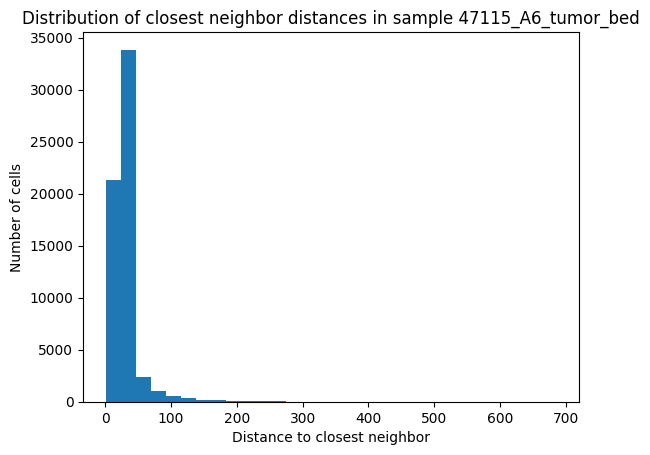

In [153]:
adata_sample = sub_df_immune[sub_df_immune["sample_region"] == "23257_A7_T3_tumor_bed"]
coords_sample = adata_sample[['xmean','ymean']]	

# Compute pairwise distances
dists = distance_matrix(coords_sample, coords_sample)

# Ignore self-distances
np.fill_diagonal(dists, np.inf)

# Get distance to closest neighbor for each cell
min_dists = dists.min(axis=1)
mean_distance = min_dists.mean()
print("Mean closest neighbor distance:", mean_distance)

# Plot histogram
plt.hist(min_dists, bins=30)
plt.xlabel("Distance to closest neighbor")
plt.ylabel("Number of cells")
plt.title("Distribution of closest neighbor distances in sample 47115_A6_tumor_bed")
plt.show()

## Spatial nieghbors by Conditions

In [154]:
def neighbor_enrichment(df, sample_col="sample_region", cell_type_col="celll_type", radius=20.0, cond=None):
    """
    Computes the counts and proportions of neighbor cell types within a given radius
    for each cell type in the dataset, aggregated over all samples.

    Returns:
        neighbor_summary_df: DataFrame with cell types as rows, neighbor types as columns,
                             values are proportion of neighbors.
    """
    neighbor_summary = []

    for cell_type_interest in df[cell_type_col].unique():
        all_neighbors = []

        for sample in df[sample_col].unique():
            df_sample = df[df[sample_col] == sample]
            coords_sample = df_sample[['xmean', 'ymean']].values

            is_interest = df_sample[cell_type_col] == cell_type_interest
            interest_coords = coords_sample[is_interest.values]

            if len(interest_coords) == 0:
                continue

            other_coords = coords_sample[~is_interest.values]
            other_cell_types = df_sample.loc[~is_interest, cell_type_col].values

            if len(other_coords) == 0:
                continue
            #cKDTree → efficient spatial index for nearest-neighbor search.
            #query_ball_point → returns indices of all other cells within radius for each cell of interest.
            tree = cKDTree(other_coords)
            neighbor_idx_list = tree.query_ball_point(interest_coords, r=radius)

            # Flatten neighbor types
            for neighbors in neighbor_idx_list:
                if len(neighbors) > 0:
                    all_neighbors.extend(other_cell_types[neighbors])

        # Count and normalize
        neighbor_counts = pd.Series(all_neighbors).value_counts()
        neighbor_proportions = neighbor_counts / neighbor_counts.sum() if len(neighbor_counts) > 0 else pd.Series()

        # Add cell type info
        for neighbor_type, prop in neighbor_proportions.items():
            neighbor_summary.append({
                "cell_type": cell_type_interest,
                "neighbor_cell_type": neighbor_type,
                "proportion": prop
            })

    neighbor_summary_df = pd.DataFrame(neighbor_summary)

    # Optional: pivot for heatmap
    pivot_df = neighbor_summary_df.pivot(index="cell_type", columns="neighbor_cell_type", values="proportion").fillna(0)

    # Plot heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_df, cmap="viridis", annot=False, fmt=".2f")
    plt.xlabel("Neighbor cell type")
    plt.ylabel("Cell type of interest")
    plt.title(f"Neighbor enrichment within {radius} microns for {cond}")
    plt.tight_layout()
    plt.show()

    return neighbor_summary_df, pivot_df


Samples to compute the neighbor analysis: ['23257_A7_T3_tumor_bed' 'BMS23-11362_C8_tumor_bed' 'S24-12214_C1_tumor'
 'BMS23-9784_A6_31737_tumor_bed' 'S23-47115_A6_tumor_bed'
 'S24-11672_G1_tumor' 'S23-18584_A5_tumor_bed' 'S24-21915_A5_tumor_bed'
 'S23-21917_A6_tumor_bed' 'BMS23-39313_C_tumor']


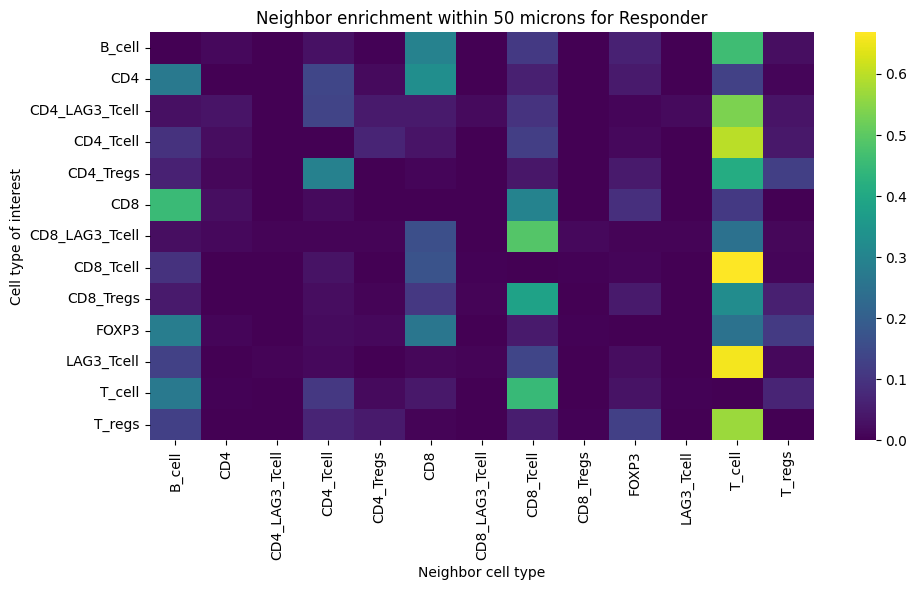

Samples to compute the neighbor analysis: ['S24-35674_A9_peritumoral_area' 'S23-38315_A3_tumor_inner'
 'BMSS23-8749_28835_tumor' 'S24-22889_A6_tumor_inner'
 'S24-22889_A6_peritumoral_area' 'S24-35674_A9_tumor_inner'
 'S23-38315_A3_peritumoral_area']


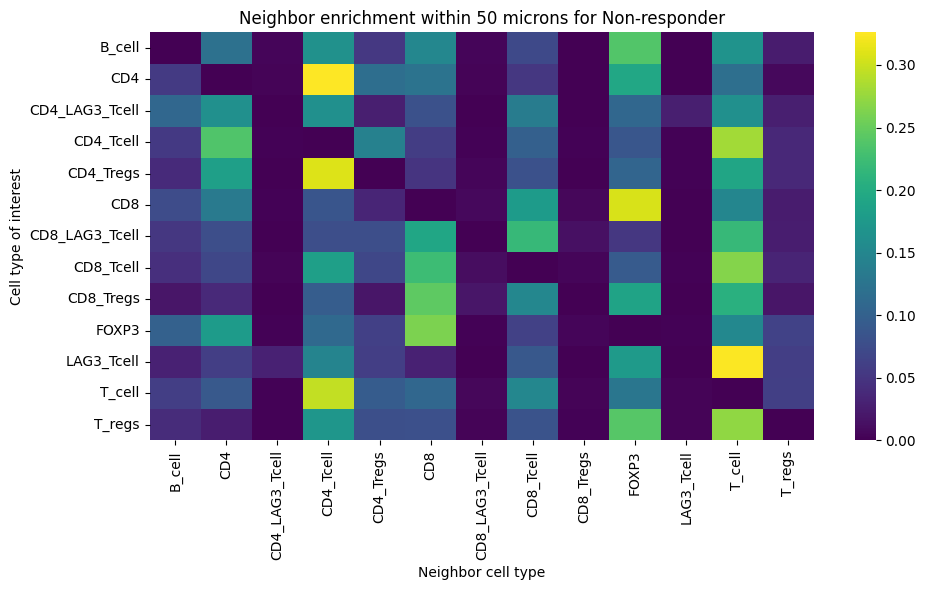

Samples to compute the neighbor analysis: ['BMS23-6679_C_tumor' 'BMS23-7393_C_tumor' 'BMS24-11260_D_tumor']


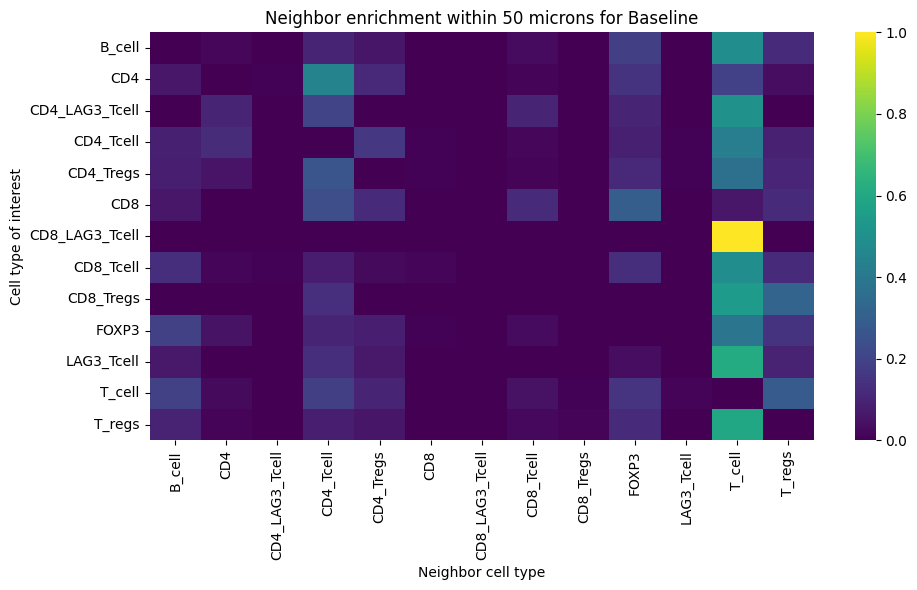

In [155]:
conditions = sub_df_immune['Condition'].unique()

neighbor_dfs = {}  # Store results per condition
pivot_dfs = {}

for cond in conditions:
    df_cond = sub_df_immune[sub_df_immune['Condition'] == cond]
    print(f"Samples to compute the neighbor analysis: {df_cond['sample_region'].unique()}")
    neighbor_summary_df, pivot_df = neighbor_enrichment(
        df_cond,
        sample_col="sample_region",
        cell_type_col="celll_type",
        radius=50,
        cond=cond
    )
    
    neighbor_dfs[cond] = neighbor_summary_df
    pivot_dfs[cond] = pivot_df

## Spatial neighbors by ROI

Samples to compute the neighbor analysis: ['23257_A7_T3_tumor_bed' 'BMS23-11362_C8_tumor_bed'
 'BMS23-9784_A6_31737_tumor_bed' 'S23-47115_A6_tumor_bed'
 'S23-18584_A5_tumor_bed' 'S24-21915_A5_tumor_bed'
 'S23-21917_A6_tumor_bed']


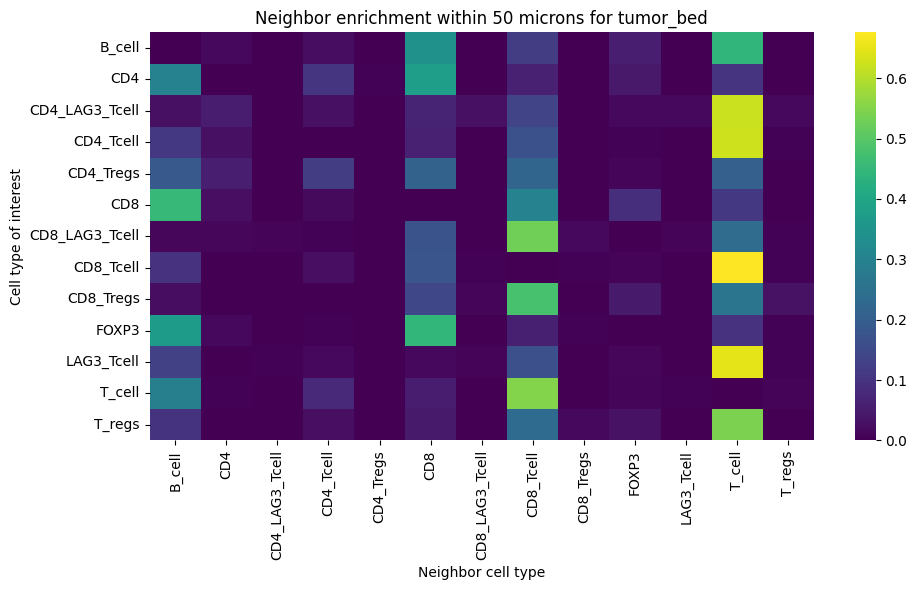

Samples to compute the neighbor analysis: ['S24-35674_A9_peritumoral_area' 'S24-22889_A6_peritumoral_area'
 'S23-38315_A3_peritumoral_area']


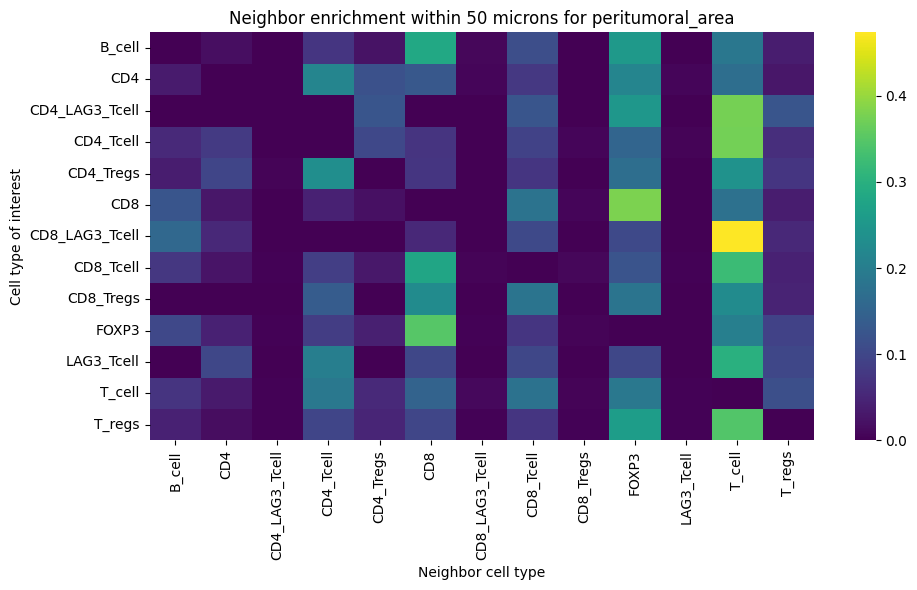

Samples to compute the neighbor analysis: ['BMS23-6679_C_tumor' 'BMSS23-8749_28835_tumor' 'S24-12214_C1_tumor'
 'S24-11672_G1_tumor' 'BMS23-7393_C_tumor' 'BMS24-11260_D_tumor'
 'BMS23-39313_C_tumor']


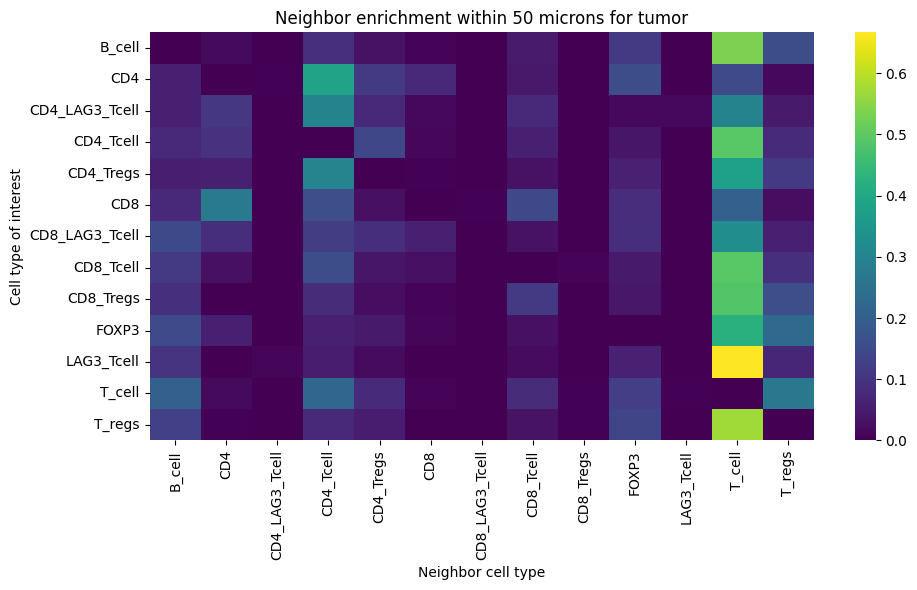

Samples to compute the neighbor analysis: ['S23-38315_A3_tumor_inner' 'S24-22889_A6_tumor_inner'
 'S24-35674_A9_tumor_inner']


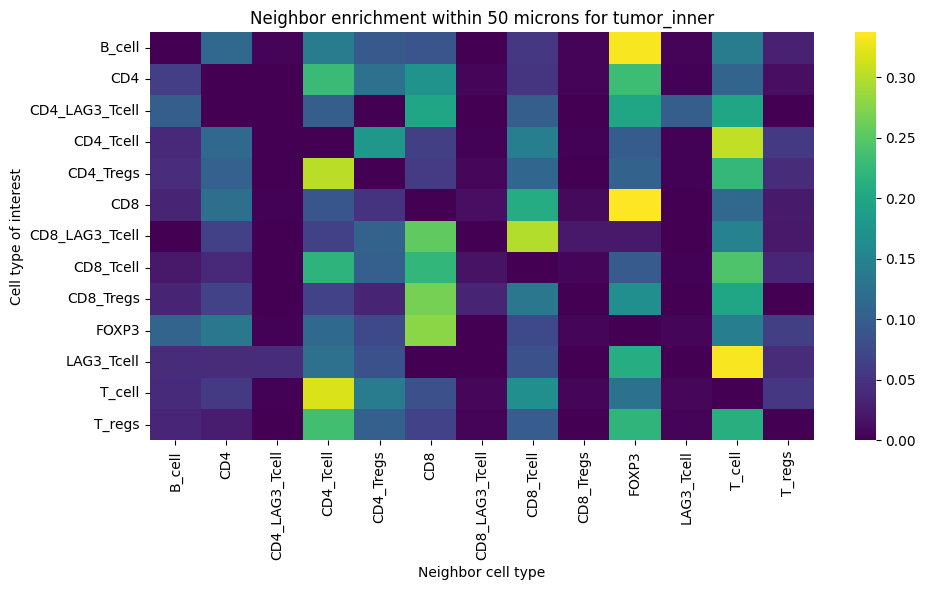

In [156]:
conditions = sub_df_immune['ROI'].unique()

neighbor_dfs = {}  # Store results per condition
pivot_dfs = {}

for cond in conditions:
    df_cond = sub_df_immune[sub_df_immune['ROI'] == cond]
    print(f"Samples to compute the neighbor analysis: {df_cond['sample_region'].unique()}")
    neighbor_summary_df, pivot_df = neighbor_enrichment(
        df_cond,
        sample_col="sample_region",
        cell_type_col="celll_type",
        radius=50,
        cond=cond
    )
    
    neighbor_dfs[cond] = neighbor_summary_df
    pivot_dfs[cond] = pivot_df

In [157]:
conditions_interest = ["Responder","Non-responder"]
ROI_interest = ["tumor_bed","tumor_inner"]

In [158]:
sub_interest1 = sub_df_immune[sub_df_immune['Condition'].isin(conditions_interest)]
sub_interest1 = sub_interest1[sub_interest1['ROI'].isin(ROI_interest)]


# Proportion differneces

## First comparison: Responders vs Non-responders
Just internal tumor and no Peritumoral area

In [159]:
interest_sample_sub = sub_df_immune[sub_df_immune['sample_region'] == "BMSS23-8749_28835_tumor"]
sub_interest1 = pd.concat([sub_interest1, interest_sample_sub], axis=0)

In [160]:
sub_interest1['Condition'].unique()

array(['Responder', 'Non-responder'], dtype=object)

In [163]:
def t_test_plot(dataframe_interest, columns_interest):
    prop_table = pd.crosstab(
        [dataframe_interest[columns_interest], dataframe_interest['sample_region']], 
        dataframe_interest['celll_type'], 
        normalize='index'
    )
    prop_table.index.names = [columns_interest, 'sample_region']
    num_cell_types = prop_table.shape[1]
    cmap = cm.get_cmap('tab20', num_cell_types)
    colors = [cmap(i) for i in range(num_cell_types)]

    ax = prop_table.plot(kind='barh', stacked=True, figsize=(10, 6), color=colors)
    
    # add separator lines between conditions
    # get index levels
    conditions = prop_table.index.get_level_values(0)
    for i in range(1, len(conditions)):
        if conditions[i] != conditions[i-1]:
            ax.axhline(i-0.5, color="black", linewidth=1)  # separator
    
    # legend outside
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(False)
    
    plt.title('Proportion of Cell Types per Sample')
    plt.xlabel('Proportion of Cells')
    plt.ylabel('Sample (grouped by Condition)')
    plt.tight_layout()
    plt.show()



    prop_table[columns_interest] = prop_table.index.get_level_values(columns_interest)
    results = []

    conditions = prop_table[columns_interest].unique()
    
    for cell_type in prop_table.columns:
        if cell_type != columns_interest:  # skip metadata
            # Loop over all pairwise comparisons
            for cond1, cond2 in combinations(conditions, 2):
                group1 = prop_table.loc[prop_table[columns_interest] == cond1, cell_type]
                group2 = prop_table.loc[prop_table[columns_interest] == cond2, cell_type]
    
                mean1 = group1.mean()
                mean2 = group2.mean()
    
                t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
    
                direction = f"up_in_{cond1}" if mean1 > mean2 else f"up_in_{cond2}"
    
                results.append({
                    "cell_type": cell_type,
                    "comparison": f"{cond1}_vs_{cond2}",
                    f"{cond1}_mean": mean1,
                    f"{cond2}_mean": mean2,
                    "t_stat": t_stat,
                    "p_val": p_val,
                    "direction": direction
                })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Correct for multiple testing (FDR)
    results_df["p_adj"] = smm.multipletests(results_df["p_val"], method="fdr_bh")[1]
    
    return ax, results_df

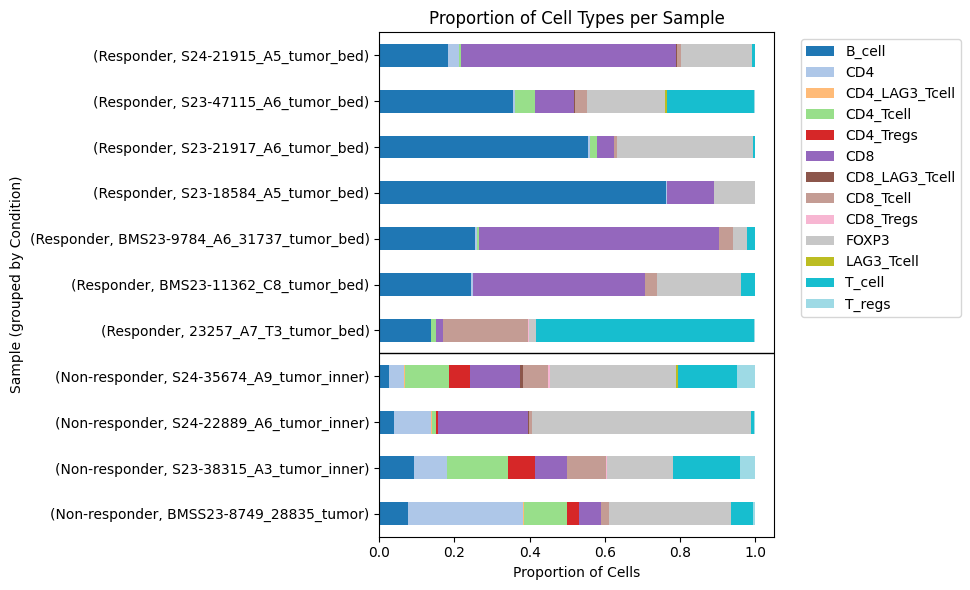

In [164]:
ax, results_df = t_test_plot(sub_interest1, "Condition")

In [165]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,Non-responder_mean,Responder_mean,t_stat,p_val,direction,p_adj
0,B_cell,Non-responder_vs_Responder,0.058797,0.355803,-3.424708,0.012665,up_in_Responder,0.164645


In [166]:
def dot_plot_for_doron(dataframe_interest, columns_interest, sample_order=None, palette=None):
    # Build proportion table
    prop_table = pd.crosstab(
        [dataframe_interest[columns_interest], dataframe_interest['sample_region']], 
        dataframe_interest['celll_type'], 
        normalize='index'
    )
    prop_table.index.names = [columns_interest, 'sample_region']
    
    # Reshape into long format
    df_long = prop_table.reset_index().melt(
        id_vars=[columns_interest, 'sample_region'], 
        var_name='cell_type', 
        value_name='proportion'
    )
    
    # Make combined label for x-axis
    df_long['cells_genotype'] = df_long[columns_interest].astype(str) + "_" + df_long['sample_region'].astype(str)
    
    # Apply custom order if provided
    if sample_order is not None:
        df_long['cells_genotype'] = pd.Categorical(df_long['cells_genotype'], categories=sample_order, ordered=True)
    
    # Use custom palette or fallback to tab20
    if palette is None:
        num_cell_types = df_long['cell_type'].nunique()
        cmap = cm.get_cmap('tab20', num_cell_types)
        palette = {ct: cmap(i) for i, ct in enumerate(df_long['cell_type'].unique())}
    
    # Plot dot plot
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_long,
        x='cells_genotype',
        y='cell_type',
        size='proportion',
        hue='cell_type',
        sizes=(20, 300),
        palette=palette
    )
    
    plt.title('Proportion of Cell Types per Sample')
    plt.xlabel('Sample Name')
    plt.ylabel('Cell Type')
    plt.xticks(rotation=90)
    plt.grid(False)
    sns.despine()
    
    # Move legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


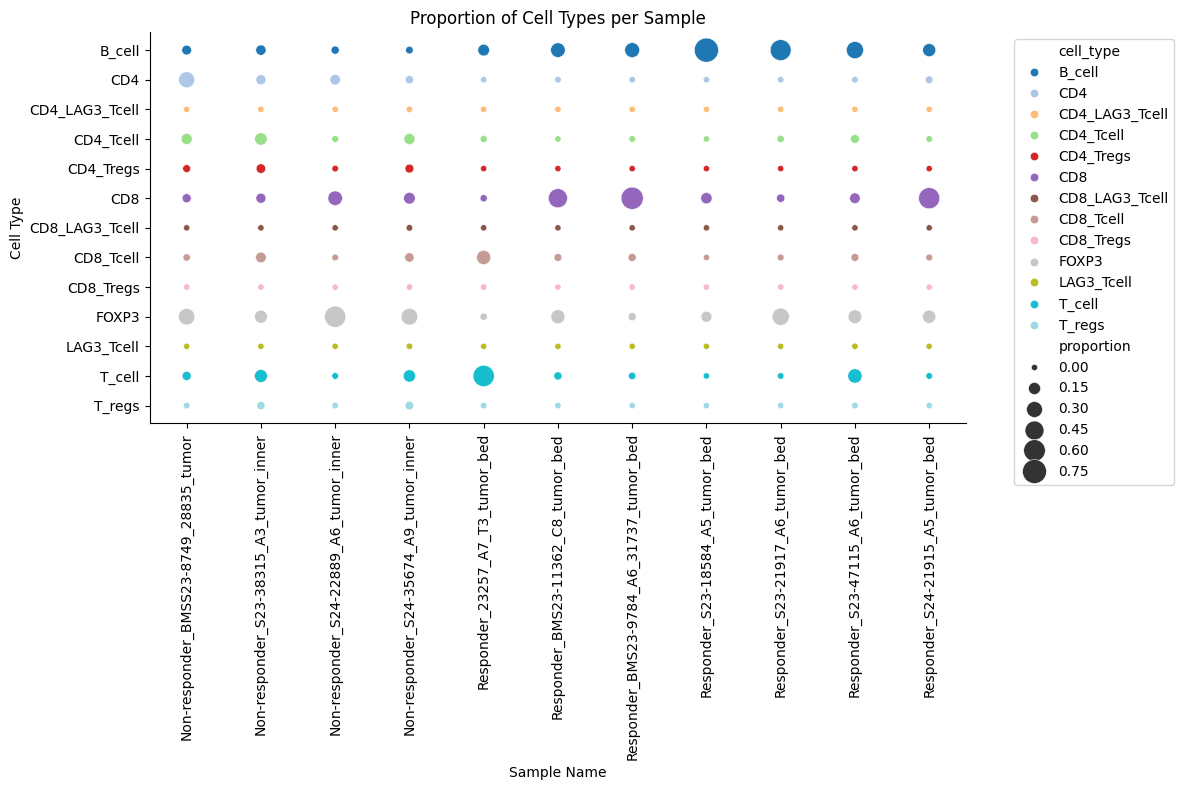

In [167]:
dot_plot_for_doron(sub_interest1, "Condition")

## Second comparison: Responders MSI high vs MSI low

In [168]:
sub_interest1 = sub_df_immune[sub_df_immune['Condition']=="Responder"]
sub_interest1 = sub_interest1[sub_interest1['ROI']!="tumor"]
sub_interest1['sample_region'].unique()

array(['23257_A7_T3_tumor_bed', 'BMS23-11362_C8_tumor_bed',
       'BMS23-9784_A6_31737_tumor_bed', 'S23-47115_A6_tumor_bed',
       'S23-18584_A5_tumor_bed', 'S24-21915_A5_tumor_bed',
       'S23-21917_A6_tumor_bed'], dtype=object)

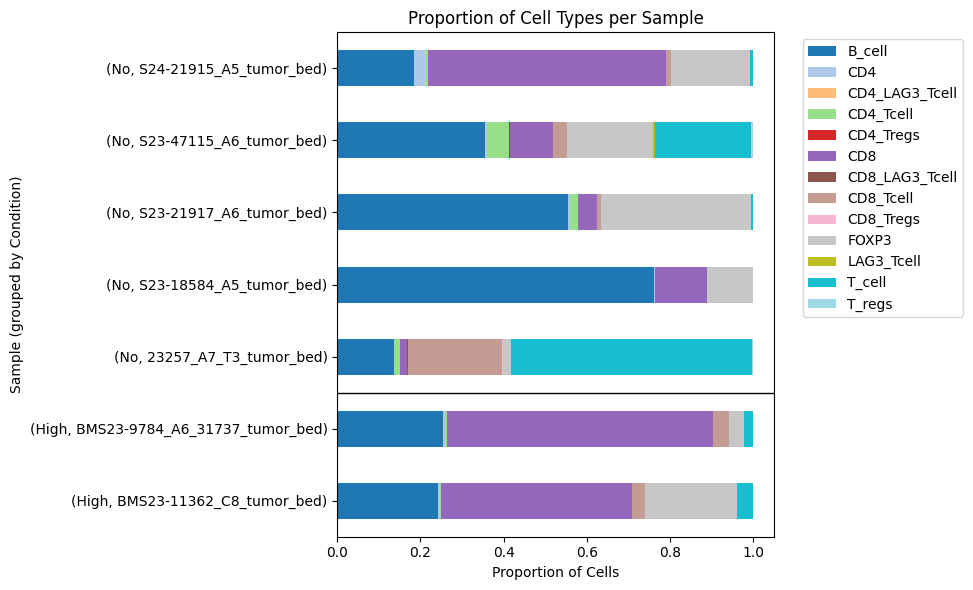

In [169]:
ax, results_df = t_test_plot(sub_interest1, "MSI")

In [170]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,High_mean,No_mean,t_stat,p_val,direction,p_adj


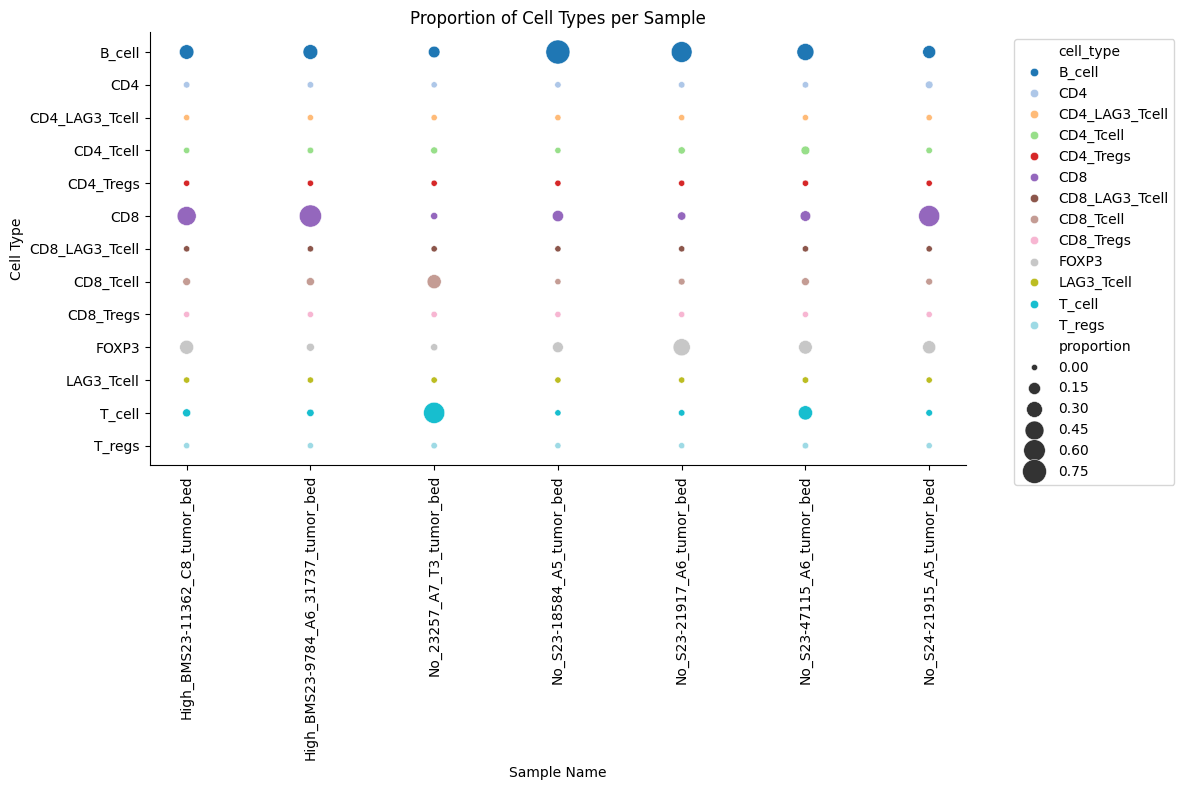

In [171]:
dot_plot_for_doron(sub_interest1, "MSI")

## Third comparison: Baseline vs Resections

In [172]:
sub_df_immune['Internal'].unique()

array(['Resection', nan, 'Baseline'], dtype=object)

In [173]:
sub_interest1 = sub_df_immune[sub_df_immune['Internal'].notna()]

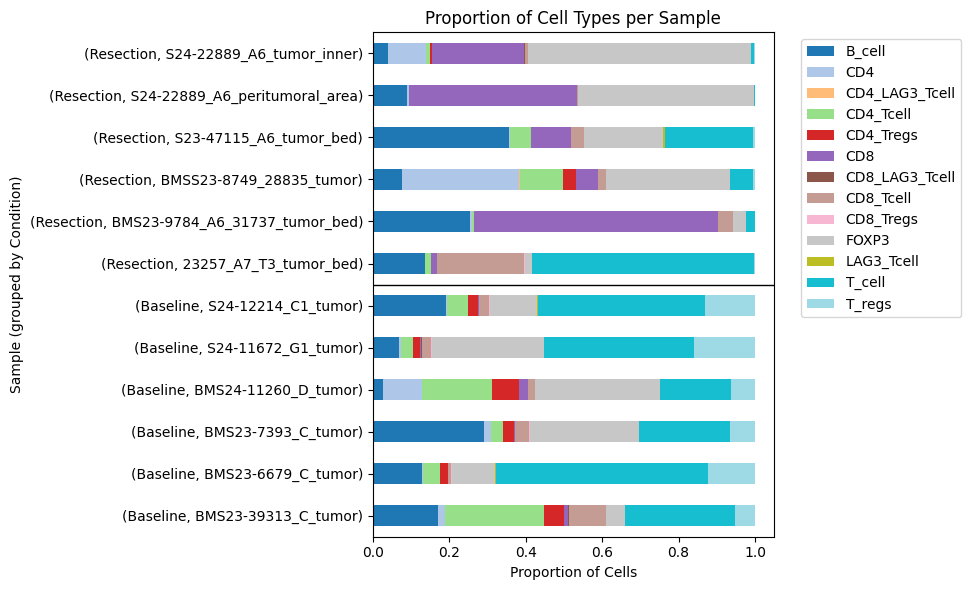

In [174]:
ax, results_df = t_test_plot(sub_interest1, "Internal")

In [175]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,Baseline_mean,Resection_mean,t_stat,p_val,direction,p_adj
4,CD4_Tregs,Baseline_vs_Resection,0.035869,0.006535,2.907168,0.019415,up_in_Baseline,0.126197
8,CD8_Tregs,Baseline_vs_Resection,0.001428,0.000442,2.378514,0.038786,up_in_Baseline,0.168072
12,T_regs,Baseline_vs_Resection,0.099071,0.002844,5.244793,0.003299,up_in_Baseline,0.042893


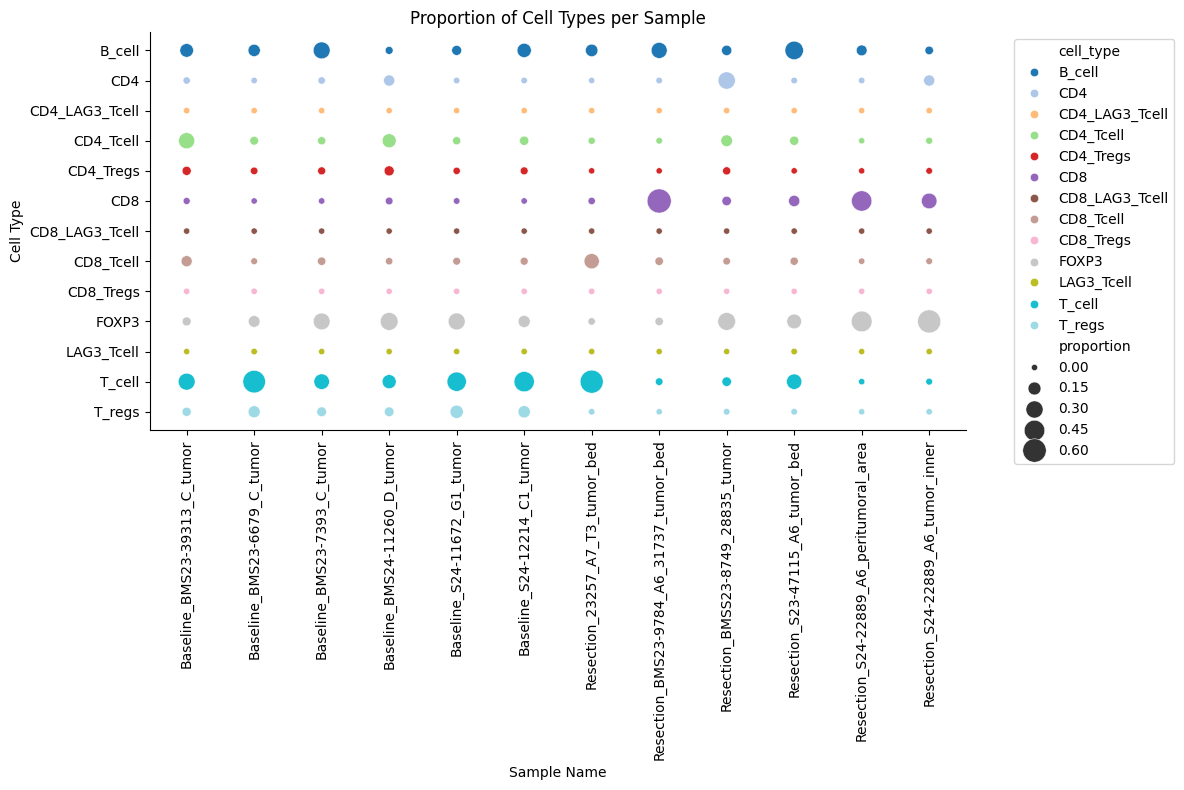

In [176]:
dot_plot_for_doron(sub_interest1, "Internal")

## Fourth comparison: within Baseline: Responders vs Non-responders

In [177]:
sub_interest1 = sub_df_immune[sub_df_immune['Internal']=="Baseline"]

In [178]:
sub_interest1['Baseline_comp']='Responder'
sub_interest1.loc[sub_interest1['sample_region'] == 'BMS24-11260_D_tumor', 'Baseline_comp'] = 'Non-responder'
sub_interest1.loc[sub_interest1['sample_region'] == 'BMS23-6679_C_tumor', 'Baseline_comp'] = 'Non-responder'

/tmp/ipykernel_3381177/2083488142.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_interest1['Baseline_comp']='Responder'


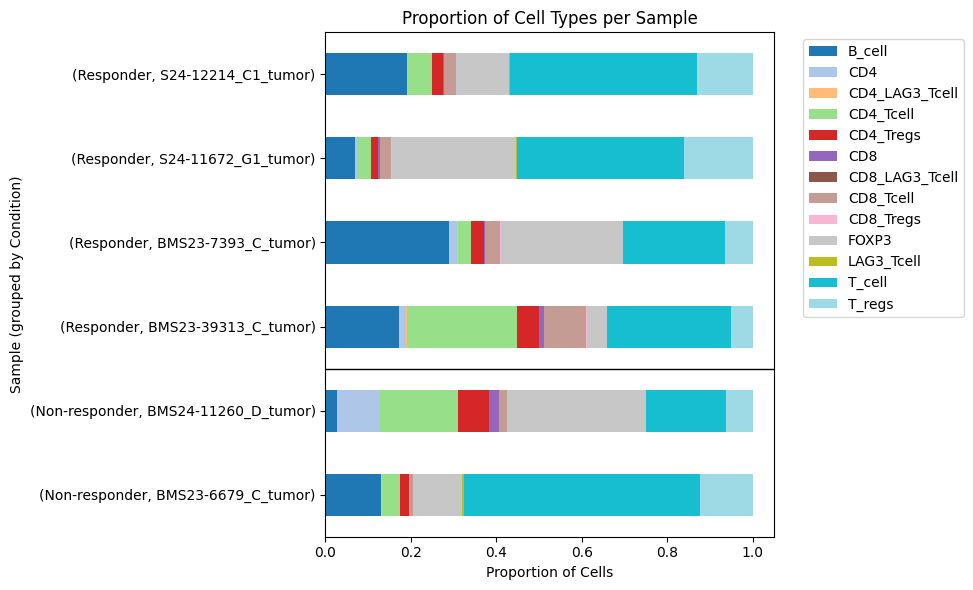

In [179]:
ax, results_df = t_test_plot(sub_interest1, "Baseline_comp")

In [180]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,Non-responder_mean,Responder_mean,t_stat,p_val,direction,p_adj


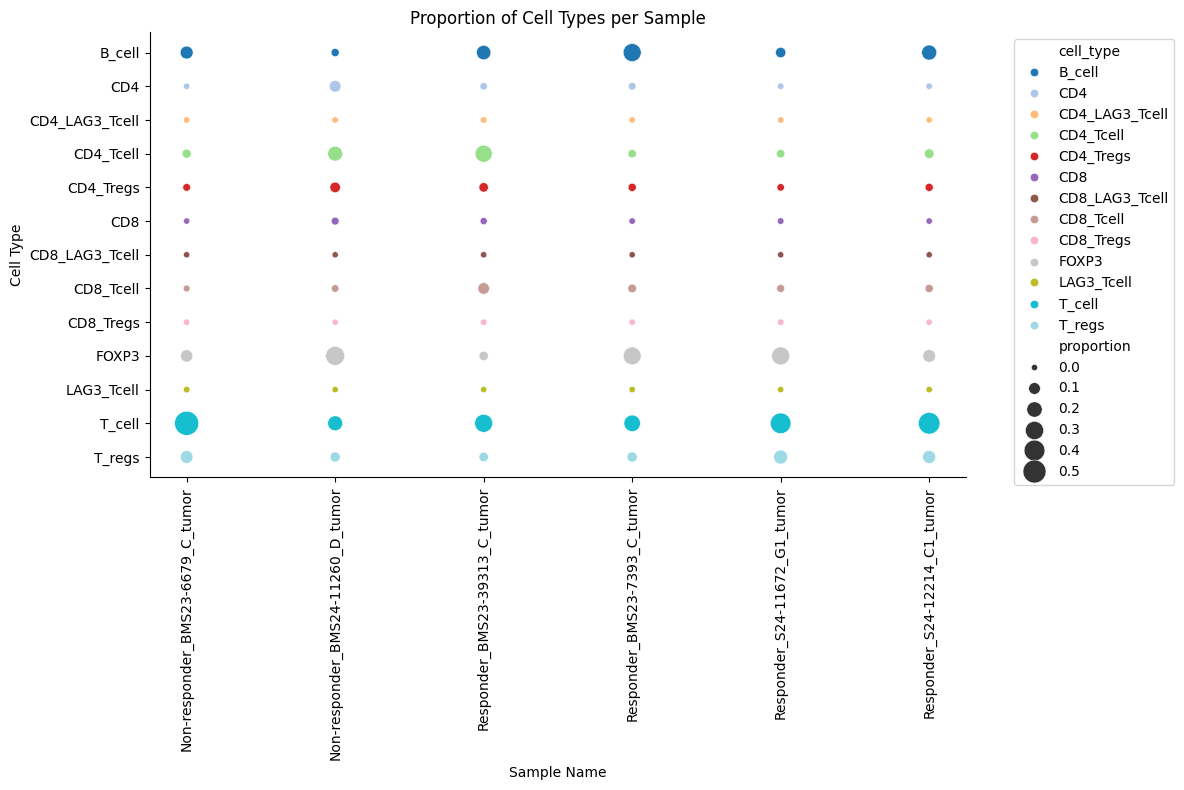

In [181]:
dot_plot_for_doron(sub_interest1, "Baseline_comp")